In [61]:
## import modules
from sympy import *
from sympy.physics.mechanics import *
init_vprinting()

In [69]:
## define System Variables
m,g,k,l0,t=symbols('m,g,k,l0,t')

#Dynamic Symbols
theta, lt=dynamicsymbols("theta,lt")

#take derivatives
theta_dot=diff(theta,t,1)
theta_ddot=diff(theta,t,2)
lt_dot=diff(lt,t,1)
lt_ddot=diff(lt,t,2)

# define the Kinetic and potential energy and Lagrangian
T=0.5*m*((((l0+lt)**2 )*(theta_dot**2))+ (lt_dot**2))
V= (0.5*k*(lt**2))-(m*g*(l0+lt)*cos(theta))
L=T-V

## Define the poem of classical Mechanics
eq1=diff(diff(L,lt_dot),t) - diff(L,lt)
eq2=diff(diff(L,theta_dot),t) - diff(L,theta)
solns=solve([eq1,eq2],[lt_ddot,theta_ddot])

## show Solution
f=Matrix([theta_dot,solns[theta_ddot],lt_dot,solns[lt_ddot]]) ## 
f_simplify=simplify(f)
x=Matrix([theta,theta_dot,lt,lt_dot])
x_dot=diff(x,t)

Eq(x_dot,f_simplify)

       ⎡               θ̇               ⎤
       ⎢                               ⎥
⎡θ̇ ⎤   ⎢     -g⋅sin(θ) - 2.0⋅lṫ⋅θ̇      ⎥
⎢  ⎥   ⎢     ────────────────────      ⎥
⎢θ̈ ⎥   ⎢           l₀ + lt             ⎥
⎢  ⎥ = ⎢                               ⎥
⎢lṫ⎥   ⎢              lṫ               ⎥
⎢  ⎥   ⎢                               ⎥
⎣lẗ⎦   ⎢           k⋅lt       2       2⎥
       ⎢g⋅cos(θ) - ──── + l₀⋅θ̇  + lt⋅θ̇ ⎥
       ⎣            m                  ⎦

In [71]:
g=f_simplify.subs({theta:'theta',theta_dot:'theta_dot',lt:'lt',lt_dot:'lt_dot'})
for i in range(4):
    print('f[{}]={}'.format(i,g[i]))

f[0]=theta_dot
f[1]=(-g*sin(theta) - 2.0*lt_dot*theta_dot)/(l0 + lt)
f[2]=lt_dot
f[3]=g*cos(theta) - k*lt/m + l0*theta_dot**2 + lt*theta_dot**2


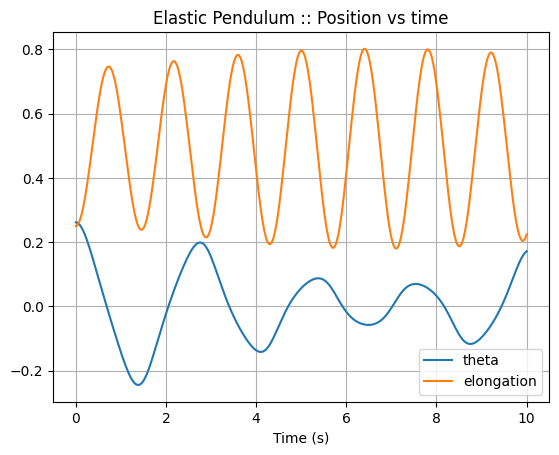

In [72]:
##Import Modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##Define Constants
g=9.81
k=20
m=1
l0=1

x0=np.array([np.deg2rad(15),0,0.25,0])

##define the function
def spring_mass_ode(t,y):
    theta=y[0]
    theta_dot=y[1]
    lt=y[2]
    lt_dot=y[3]
    return (
        theta_dot,
        (-g*sin(theta) - 2.0*lt_dot*theta_dot)/(l0 + lt),
        lt_dot,
        g*cos(theta) - k*lt/m + l0*theta_dot**2 + lt*theta_dot**2)

## solve 
sol = solve_ivp(spring_mass_ode,[0,10],x0,t_eval=np.linspace(0,10,10*30))

##output
theta=sol.y[0]
lt=sol.y[2]
t=sol.t

#plot theta and lt vs time
plt.plot(t,theta,label="theta")
plt.plot(t,lt,label="elongation")
plt.legend()
plt.grid()
plt.xlabel("Time (s)")
plt.title("Elastic Pendulum :: Position vs time")
plt.show()

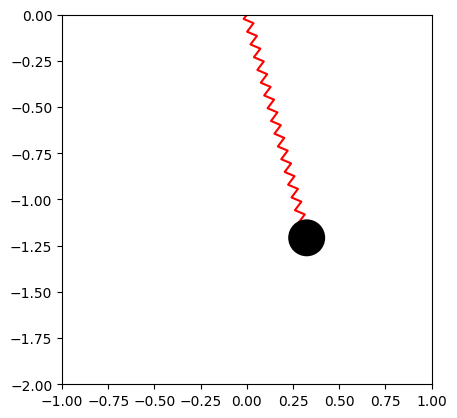

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.lines import Line2D
from matplotlib.transforms import Affine2D

fig=plt.figure()
ax=fig.add_subplot(aspect="equal")
ax.set_xlim(-1,1)
ax.set_ylim(-2,0)

def generate_spring(n):
    data=np.zeros((2,n+2))
    data[:,-1]=[0,-1]
    for i in range(1,n+1):
        data[0,i]= -1/(2*n) if i%2 else 1/(2*n)
        data[1,i]=-(2*i-1)/(2*n)
    return data

## initial conditions
theta=np.deg2rad(15)
lt=0.25
l0=1
spring_len=l0+lt

## Position of mass
px= (spring_len)*np.sin(theta)
py=-(spring_len)*np.cos(theta)
circle=ax.add_patch(plt.Circle((px,py),0.1,fc="k",zorder=3))

## spring
S=Affine2D().scale(2/spring_len,spring_len).rotate(theta).get_matrix()
data=l0*np.append(generate_spring(35),np.ones((1,35+2)),axis=0)
trans_data= S@data

spring=Line2D(trans_data[0,:],trans_data[1,:],color='r')
ax.add_line(spring)
plt.savefig('elastic_pendulum_initial_position.png')

In [ ]:
theta 

In [109]:
d=np.zeros((2,2))
#print(d)
d[1,1]=-1
print(d) 

[[ 0.  0.]
 [ 0. -1.]]
